In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import iplot

from sklearn.model_selection import train_test_split
from math import sqrt
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error as mse
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

import warnings
warnings.filterwarnings("ignore")

In [20]:
train_df=pd.read_csv(r'F:\IEEE datasets\train.csv')
features_df=pd.read_csv(r'F:\IEEE datasets\features.csv')
stores_df=pd.read_csv(r'F:\IEEE datasets\stores.csv')
test_df=pd.read_csv(r'F:\IEEE datasets\test.csv')

In [22]:
# BASIC EXPLORATION
# ============================================
print("Train Shape:", train_df.shape)
print("Features Shape:", features_df.shape)
print("Stores Shape:", stores_df.shape)
print("Test Shape:", test_df.shape)

print("\nTrain Columns:", train_df.columns)
print("\nTrain Head:\n", train_df.head())


Train Shape: (421570, 5)
Features Shape: (8190, 12)
Stores Shape: (45, 3)
Test Shape: (115064, 4)

Train Columns: Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')

Train Head:
    Store  Dept        Date  Weekly_Sales  IsHoliday
0      1     1  2010-02-05      24924.50      False
1      1     1  2010-02-12      46039.49       True
2      1     1  2010-02-19      41595.55      False
3      1     1  2010-02-26      19403.54      False
4      1     1  2010-03-05      21827.90      False


Train Nulls:
 Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

Features Nulls:
 Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64

Stores Nulls:
 Store    0
Type     0
Size     0
dtype: int64

Train Describe:
                Store           Dept   Weekly_Sales
count  421570.000000  421570.000000  421570.000000
mean       22.200546      44.260317   15981.258123
std        12.785297      30.492054   22711.183519
min         1.000000       1.000000   -4988.940000
25%        11.000000      18.000000    2079.650000
50%        22.000000      37.000000    7612.030000
75%        33.000000      74.000000   20205.852500
max        45.000000      99.000000  693099.360000


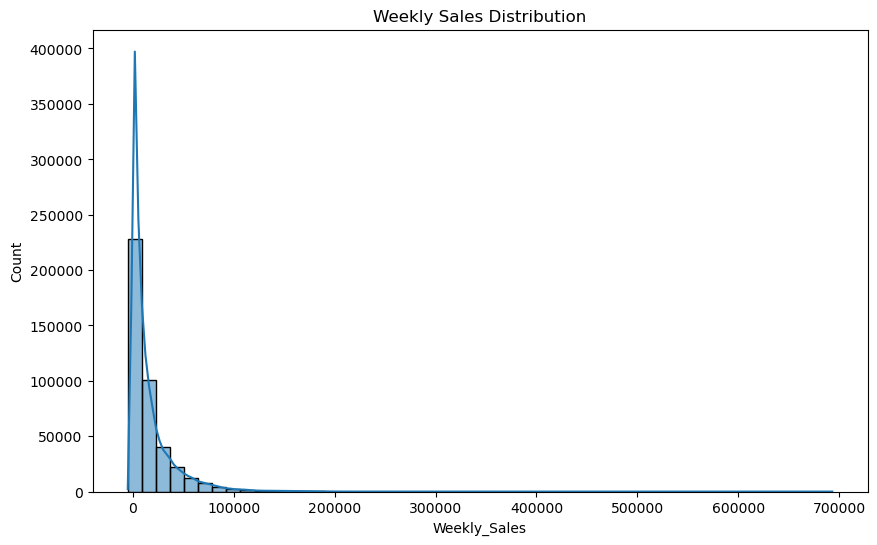

In [24]:
# EDA
# ============================================
print("Train Nulls:\n", train_df.isnull().sum())
print("\nFeatures Nulls:\n", features_df.isnull().sum())
print("\nStores Nulls:\n", stores_df.isnull().sum())

print("\nTrain Describe:\n", train_df.describe())

# Weekly Sales Distribution
plt.figure(figsize=(10,6))
sns.histplot(train_df['Weekly_Sales'], bins=50, kde=True)
plt.title("Weekly Sales Distribution")
plt.show()


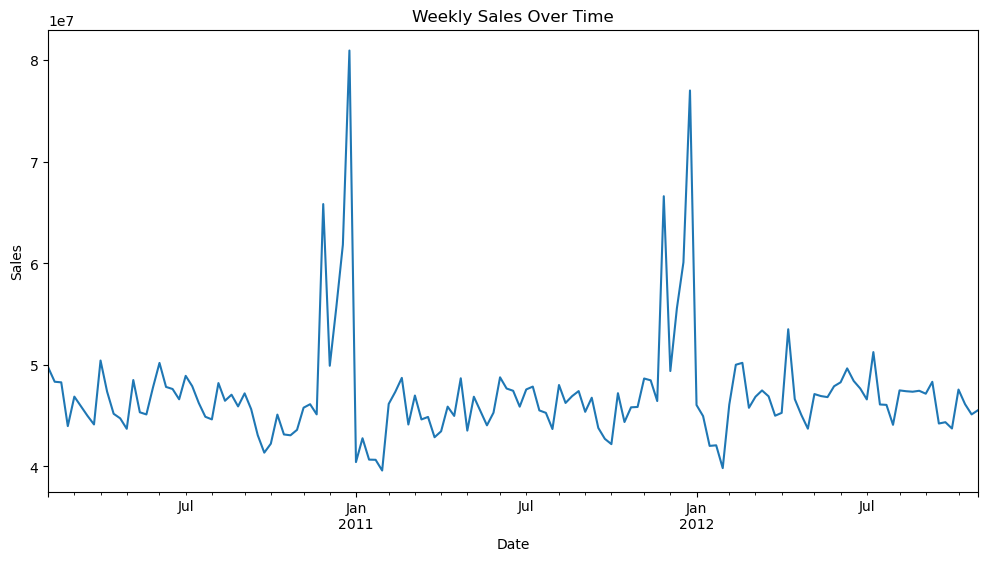

In [26]:
# TIME SERIES PREPARATION
# ============================================
# Convert Date to datetime
train_df['Date'] = pd.to_datetime(train_df['Date'])
train_df = train_df.sort_values('Date')

# Set Date as index and focus on Weekly_Sales
ts = train_df.set_index('Date')['Weekly_Sales']

# Resample Weekly Sales
ts_weekly = ts.resample('W').sum()

# Plot
plt.figure(figsize=(12,6))
ts_weekly.plot()
plt.title('Weekly Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()


ARIMA Forecast:
 2012-11-04    4.631238e+07
2012-11-11    4.666243e+07
2012-11-18    4.682193e+07
2012-11-25    4.689460e+07
2012-12-02    4.692771e+07
2012-12-09    4.694279e+07
2012-12-16    4.694967e+07
2012-12-23    4.695280e+07
2012-12-30    4.695423e+07
2013-01-06    4.695488e+07
Freq: W-SUN, Name: predicted_mean, dtype: float64


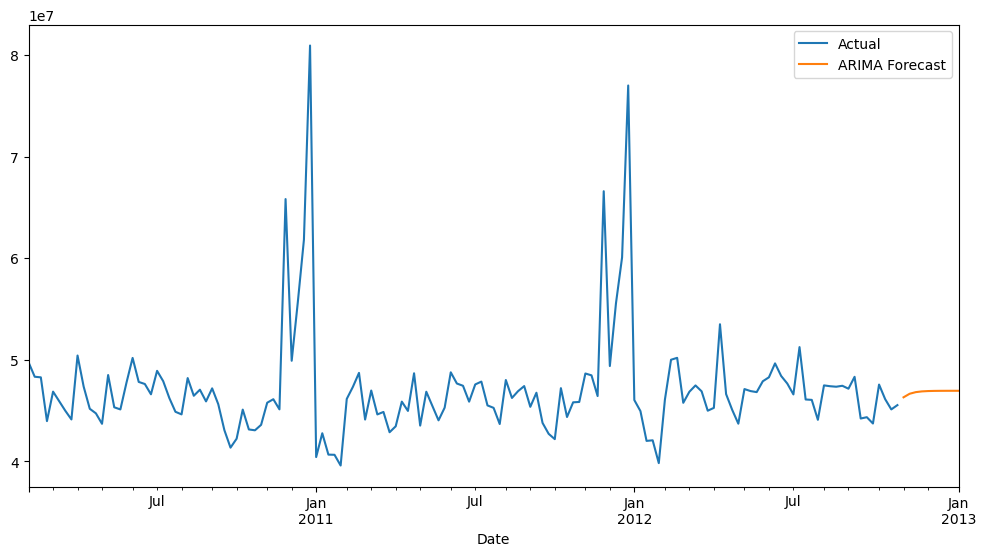

In [28]:
# ARIMA MODEL
# ============================================
arima_model = ARIMA(ts_weekly, order=(1,1,1))
arima_result = arima_model.fit()

# Forecast next 10 weeks
arima_forecast = arima_result.forecast(steps=10)
print("ARIMA Forecast:\n", arima_forecast)

plt.figure(figsize=(12,6))
ts_weekly.plot(label='Actual')
arima_forecast.plot(label='ARIMA Forecast')
plt.legend()
plt.show()


SARIMA Forecast:
 2012-11-04    4.796267e+07
2012-11-11    4.783853e+07
2012-11-18    4.613570e+07
2012-11-25    6.356694e+07
2012-12-02    4.877948e+07
2012-12-09    5.408624e+07
2012-12-16    5.807761e+07
2012-12-23    7.279528e+07
2012-12-30    4.557115e+07
2013-01-06    4.481319e+07
Freq: W-SUN, Name: predicted_mean, dtype: float64


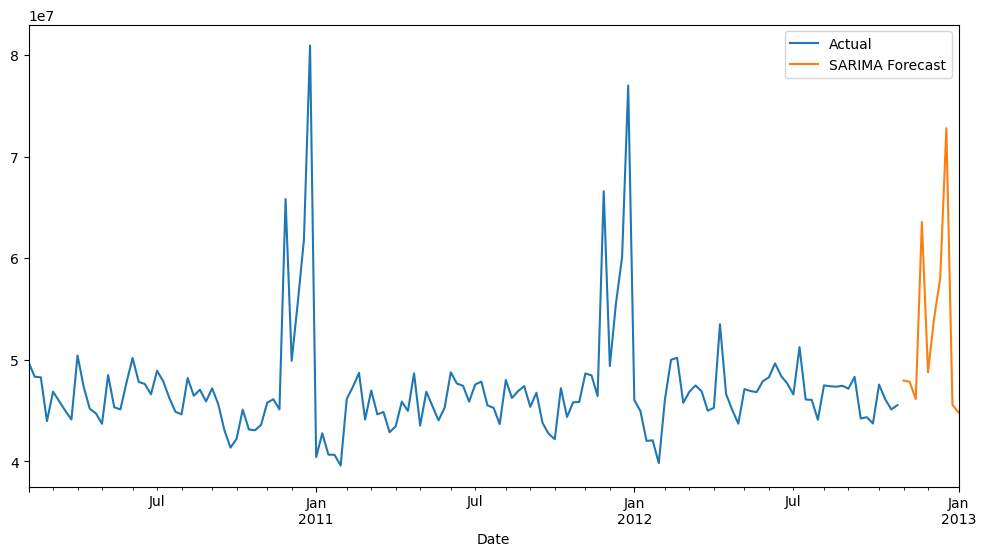

In [30]:
# SARIMA MODEL
# ============================================
sarima_model = SARIMAX(ts_weekly, order=(1,1,1), seasonal_order=(1,1,1,52))
sarima_result = sarima_model.fit()

# Forecast next 10 weeks
sarima_forecast = sarima_result.forecast(steps=10)
print("SARIMA Forecast:\n", sarima_forecast)

plt.figure(figsize=(12,6))
ts_weekly.plot(label='Actual')
sarima_forecast.plot(label='SARIMA Forecast')
plt.legend()
plt.show()


In [32]:
# METRICS EVALUATION
# ============================================
# Predictions for evaluation (using in-sample fit)
arima_pred = arima_result.predict(start=0, end=len(ts_weekly)-1)
sarima_pred = sarima_result.predict(start=0, end=len(ts_weekly)-1)

# ARIMA Metrics
print("ARIMA MAE:", mean_absolute_error(ts_weekly, arima_pred))
print("ARIMA MSE:", mean_squared_error(ts_weekly, arima_pred))
print("ARIMA RMSE:", np.sqrt(mean_squared_error(ts_weekly, arima_pred)))

# SARIMA Metrics
print("\nSARIMA MAE:", mean_absolute_error(ts_weekly, sarima_pred))
print("SARIMA MSE:", mean_squared_error(ts_weekly, sarima_pred))
print("SARIMA RMSE:", np.sqrt(mean_squared_error(ts_weekly, sarima_pred)))

ARIMA MAE: 3506885.645857598
ARIMA MSE: 48307762202900.484
ARIMA RMSE: 6950378.565438036

SARIMA MAE: 2827826.198695482
SARIMA MSE: 47318400713645.74
SARIMA RMSE: 6878837.162896483
